In [1]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [2]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("soybean_large.csv")

# View basic info
print(df.head())
print(df.info())

                    type date plant-stand  ... seed-size shriveling roots
0  diaporthe-stem-canker    6           0  ...         0          0     0
1  diaporthe-stem-canker    4           0  ...         0          0     0
2  diaporthe-stem-canker    3           0  ...         0          0     0
3  diaporthe-stem-canker    3           0  ...         0          0     0
4  diaporthe-stem-canker    6           0  ...         0          0     0

[5 rows x 36 columns]
<class 'pandas.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   type             307 non-null    str  
 1   date             307 non-null    str  
 2   plant-stand      307 non-null    str  
 3   precip           307 non-null    str  
 4   temp             307 non-null    str  
 5   hail             307 non-null    str  
 6   crop-hist        307 non-null    str  
 7   area-damaged     307 non-null    str  

In [3]:
# =========================
# 3. Handle Missing Values
# =========================
# Replace missing values (if any) with mode for categorical data
for col in df.columns:
    df[col] = df[col].replace("?", np.nan)
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [4]:
# =========================
# 4. Encode Categorical Features
# =========================
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [5]:
# =========================
# 5. Split Features & Target
# =========================
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column = target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# =========================
# 6. Decision Tree Model
# =========================
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9838709677419355
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         2

    accuracy                           0.98        62
   macro avg       0.95      0.99      0.97        62
weighted avg       0.99      0.98      0.98        62



In [7]:
# =========================
# 7. Random Forest Model
# =========================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9838709677419355
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        54
           1       1.00      0.83      0.91         6
           2       1.00      1.00      1.00         2

    accuracy                           0.98        62
   macro avg       0.99      0.94      0.97        62
weighted avg       0.98      0.98      0.98        62



In [8]:
# =========================
# 8. Extra Trees (Random Trees)
# =========================
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
et_model.fit(X_train, y_train)

et_pred = et_model.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, et_pred))
print(classification_report(y_test, et_pred))

Extra Trees Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         2

    accuracy                           1.00        62
   macro avg       1.00      1.00      1.00        62
weighted avg       1.00      1.00      1.00        62



In [9]:
# =========================
# 9. Confusion Matrix Example (Random Forest)
# =========================
print(confusion_matrix(y_test, rf_pred))

[[54  0  0]
 [ 1  5  0]
 [ 0  0  2]]


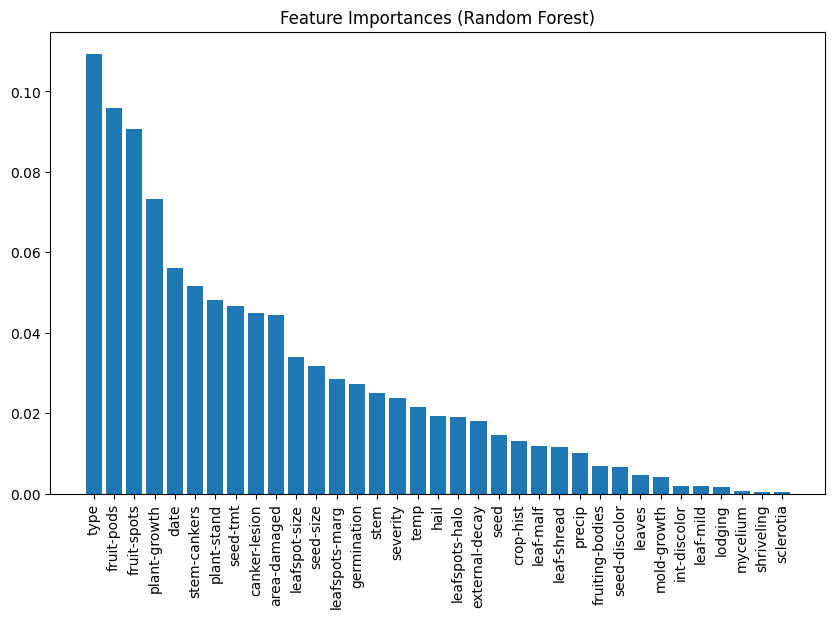

In [10]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()